<a href="https://colab.research.google.com/github/0921-janice/0921-janice/blob/main/XGB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CONFIG

In [1]:
MODEL = "XGB"               # Options: "PLS", "SVM", "RF", "XGBoost"
FEATURE_SELECTION = "None"    # Options: "GA", "None"
RANDOM_SEED = 40
THRESHOLD = 0.5             # Starting threshold — will be optimized automatically

# PLS-specific
PLS_COMPONENT_OPTIONS = [2, 3, 5, 7, 10]

# SVM-specific
SVM_C_OPTIONS = [0.01, 0.1, 1, 10, 100]
SVM_KERNEL = "rbf"

# RF-specific
RF_ESTIMATOR_OPTIONS = [50, 100, 200, 300]

# XGBoost-specific
XGB_ESTIMATOR_OPTIONS = [100, 200, 300, 500]
XGB_LEARNING_RATE_OPTIONS = [0.01, 0.05, 0.1, 0.2]
XGB_MAX_DEPTH_OPTIONS = [3, 5, 7, 9]

# GA-specific (only used when FEATURE_SELECTION = "GA")
GA_POPULATION_SIZE = 50
GA_N_GENERATIONS = 10
GA_MUTATION_RATE = 0.02
GA_ALPHA = 0.3              # 0 = all accuracy, 1 = all sparsity

#IMPORTS

In [2]:
import numpy as np
import pandas as pd
import random
import re
import sklearn.base
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from scipy.signal import savgol_filter
from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.cross_decomposition import PLSRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    balanced_accuracy_score,
    matthews_corrcoef
)

# LOAD & PREPROCESS DATA

In [3]:
df_raw = pd.read_csv('/content/New_Normalized.csv')

meta = df_raw.iloc[:, :2]
X_raw = df_raw.iloc[:, 2:].values

# Mean-center + derivative
X_centered = X_raw - X_raw.mean(axis=0)
X_deriv = np.gradient(X_centered, axis=1)

X_df = pd.DataFrame(X_deriv, columns=df_raw.columns[2:])
df_processed = pd.concat([meta, X_df], axis=1)
df_processed.columns.values[0] = "SampleID"
df_processed.columns.values[1] = "Label"
df = df_processed


# PARSE GROUPS & ENCODE LABELS

In [4]:
def parse_group(spec):
    match = re.match(r"(FE|UK)\s+(\d+),", spec)
    if match:
        return f"{match.group(1)}_{match.group(2)}"
    else:
        raise ValueError(f"Cannot parse Specimen: {spec}")

df["group"] = df["SampleID"].apply(parse_group)
df["y"] = df["Label"].map({"Fentanyl": 1, "Control": 0})

if df["y"].isnull().any():
    raise ValueError("Unknown labels found")

X = df.drop(columns=["SampleID", "Label", "group", "y"]).values
y = df["y"].values
groups = df["group"].values

# TRAIN / TEST SPLIT

In [5]:
rng = np.random.RandomState(RANDOM_SEED)
unique_groups = np.unique(groups)
rng.shuffle(unique_groups)

n_test_groups = int(len(unique_groups) * 0.3)
test_groups  = unique_groups[:n_test_groups]
train_groups = unique_groups[n_test_groups:]

train_mask = np.isin(groups, train_groups)
test_mask  = np.isin(groups, test_groups)

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
groups_train = groups[train_mask]
groups_test  = groups[test_mask]

print(f"Train subjects: {len(np.unique(groups_train))}")
print(f"Test subjects:  {len(np.unique(test_groups))}")

y_series = pd.Series(y)
print("\nTrain class distribution:")
print(y_series[train_mask].value_counts().sort_index().rename({0: "Control", 1: "Fentanyl"}))
print("\nTest class distribution:")
print(y_series[test_mask].value_counts().sort_index().rename({0: "Control", 1: "Fentanyl"}))

Train subjects: 26
Test subjects:  10

Train class distribution:
Control     140
Fentanyl    120
Name: count, dtype: int64

Test class distribution:
Control     60
Fentanyl    40
Name: count, dtype: int64


# MODEL & FEATURE SELECTION FUNCTIONS

In [6]:
# ─────────────────────────────────────────
# HELPER: PREDICT SCORES (model-agnostic)
# Works for PLS (uses .predict), SVM/RF (uses .predict_proba)
# ─────────────────────────────────────────

def get_scores(model, X):
    """Return continuous prediction scores regardless of model type."""
    if isinstance(model, PLSRegression):
        return model.predict(X).ravel()
    elif hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    else:
        return model.decision_function(X)


# ─────────────────────────────────────────
# HELPER: METRICS
# ─────────────────────────────────────────

def compute_metrics(y_true, y_score, threshold=THRESHOLD):
    y_pred = (y_score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "Accuracy":          accuracy_score(y_true, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision":         precision_score(y_true, y_pred, zero_division=0),
        "Recall":            recall_score(y_true, y_pred),
        "F1":                f1_score(y_true, y_pred),
        "Specificity":       tn / (tn + fp) if (tn + fp) > 0 else 0.0,
        "Sensitivity":       tp / (tp + fn) if (tp + fn) > 0 else 0.0,
        "MCC":               matthews_corrcoef(y_true, y_pred),
        "ROC_AUC":           roc_auc_score(y_true, y_score),
    }


def plot_roc_curve(y_true, y_prob, title="ROC Curve"):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc:.3f})", linewidth=2)
    plt.plot([0, 1], [0, 1], "k--", label="Random Classifier", linewidth=1)
    plt.xlabel("False Positive Rate", fontsize=12)
    plt.ylabel("True Positive Rate", fontsize=12)
    plt.title(title, fontsize=14, fontweight="bold")
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────
# MODEL FACTORY
# Returns a fresh, untrained model based on CONFIG
# ─────────────────────────────────────────

def get_model(model_name, **kwargs):
    """
    Returns an untrained model instance.
    Pass hyperparams as kwargs (e.g. n_components=5, C=1.0).
    """
    if model_name == "PLS":
        n = kwargs.get("n_components", 5)
        return PLSRegression(n_components=n)

    elif model_name == "SVM":
        C = kwargs.get("C", 1.0)
        # SVM needs scaled data — wrap in a pipeline
        return Pipeline([
            ("scaler", StandardScaler()),
            ("svm", SVC(C=C, kernel=SVM_KERNEL, probability=True,
                        random_state=RANDOM_SEED))
        ])

    elif model_name == "RF":
        n_est = kwargs.get("n_estimators", 100)
        return RandomForestClassifier(n_estimators=n_est,
                                      random_state=RANDOM_SEED, n_jobs=-1)

    elif model_name == "XGB":
        n_est = kwargs.get("n_estimators", 200)
        lr = kwargs.get("learning_rate", 0.1)
        depth = kwargs.get("max_depth", 6)

        return XGBClassifier(
            n_estimators=n_est,
            learning_rate=lr,
            max_depth=depth,
            random_state=RANDOM_SEED,
            use_label_encoder=False,
            eval_metric="logloss",
            n_jobs=-1
        )

    else:
        raise ValueError(f"Unknown model: {model_name}. Choose 'PLS', 'SVM', or 'RF'.")

# HYPERPARAMETER TUNING

In [7]:
def tune_hyperparams(model_name, X, y, groups, cv=5):
    """
    Tunes the primary hyperparameter for the chosen model using GroupKFold.
    Returns: (best_param_value, cv_results_dataframe)
    """
    gkf = GroupKFold(n_splits=cv)

    # Define which hyperparameter to search over
    if model_name == "PLS":
        param_name = "n_components"
        param_options = PLS_COMPONENT_OPTIONS
    elif model_name == "SVM":
        param_name = "C"
        param_options = SVM_C_OPTIONS
    elif model_name == "RF":
        param_name = "n_estimators"
        param_options = RF_ESTIMATOR_OPTIONS
    elif model_name == "XGB":
        param_name = "n_estimators"
        param_options = XGB_ESTIMATOR_OPTIONS
    else:
        raise ValueError(f"Unknown model: {model_name}")

    all_rows = []

    for param_val in param_options:
        for fold, (tr_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
            X_tr, X_val = X[tr_idx], X[val_idx]
            y_tr, y_val = y[tr_idx], y[val_idx]

            model = get_model(model_name, **{param_name: param_val})
            model.fit(X_tr, y_tr)
            y_score = get_scores(model, X_val)

            metrics = compute_metrics(y_val, y_score)
            all_rows.append({param_name: param_val, "Fold": fold, **metrics})

    cv_results = pd.DataFrame(all_rows)

    # Pick best by MCC
    best_param = (
        cv_results.groupby(param_name)["MCC"]
        .mean()
        .idxmax()
    )

    summary = cv_results.groupby(param_name).agg(["mean", "std"]).round(3)
    print(f"\nCV Summary (by {param_name}):")
    print(summary)
    print(f"\nOptimal {param_name} (by MCC): {best_param}")

    return best_param, cv_results

# CV PREDICTIONS (out-of-fold)

In [8]:
def get_cv_predictions(model_name, best_param, X, y, groups, cv=5):
    """
    Generates out-of-fold predictions using the best hyperparameter.
    Returns array of scores aligned with y.
    """
    param_name = {"PLS": "n_components", "SVM": "C", "RF": "n_estimators", "XGB": "n_estimators"}[model_name]

    gkf = GroupKFold(n_splits=cv)
    oof_scores = np.zeros(len(y))

    for tr_idx, val_idx in gkf.split(X, y, groups):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr = y[tr_idx]

        model = get_model(model_name, **{param_name: best_param})
        model.fit(X_tr, y_tr)
        oof_scores[val_idx] = get_scores(model, X_val)

    return oof_scores

# FEATURE SELECTION FUNCTIONS

In [9]:
# ─────────────────────────────────────────
# GA FITNESS FUNCTION
# ─────────────────────────────────────────

def ga_fitness(chromosome, X, y, model_name, cv=5):
    """Evaluate a chromosome. Returns penalized CV accuracy."""
    selected = np.where(chromosome == 1)[0]
    if len(selected) == 0:
        return 0.0

    X_sel = X[:, selected]
    kf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_SEED)
    fold_accs = []

    for tr_idx, val_idx in kf.split(X_sel, y):
        model = get_model(model_name)  # uses default hyperparam for GA fitness
        model.fit(X_sel[tr_idx], y[tr_idx])
        scores = get_scores(model, X_sel[val_idx])
        preds = (scores >= THRESHOLD).astype(int)
        fold_accs.append(accuracy_score(y[val_idx], preds))

    feature_ratio = len(selected) / X.shape[1]
    return (1 - GA_ALPHA) * np.mean(fold_accs) + GA_ALPHA * (1 - feature_ratio)


# ─────────────────────────────────────────
# GENETIC ALGORITHM CLASS
# ─────────────────────────────────────────

class GeneticAlgorithmFS:
    def __init__(self, n_features, model_name,
                 population_size=GA_POPULATION_SIZE,
                 n_generations=GA_N_GENERATIONS,
                 crossover_rate=0.8,
                 mutation_rate=GA_MUTATION_RATE,
                 elite_size=5):
        self.n_features     = n_features
        self.model_name     = model_name
        self.population_size = population_size
        self.n_generations  = n_generations
        self.crossover_rate = crossover_rate
        self.mutation_rate  = mutation_rate
        self.elite_size     = elite_size

        self.best_fitness_history = []
        self.avg_fitness_history  = []
        self.best_chromosome      = None
        self.best_fitness         = -np.inf

    def _init_population(self):
        return [(np.random.rand(self.n_features) < 0.2).astype(int)
                for _ in range(self.population_size)]

    def _selection(self, population, fitnesses):
        selected = []
        for _ in range(len(population)):
            candidates = random.sample(range(len(population)), 3)
            best = max(candidates, key=lambda i: fitnesses[i])
            selected.append(population[best].copy())
        return selected

    def _crossover(self, p1, p2):
        if random.random() < self.crossover_rate:
            pt = random.randint(1, self.n_features - 1)
            return (np.concatenate([p1[:pt], p2[pt:]]),
                    np.concatenate([p2[:pt], p1[pt:]]))
        return p1.copy(), p2.copy()

    def _mutate(self, chromosome):
        for i in range(self.n_features):
            if random.random() < self.mutation_rate:
                chromosome[i] = 1 - chromosome[i]
        return chromosome

    def run(self, X, y):
        print("Initializing GA population...")
        population = self._init_population()

        for gen in range(self.n_generations):
            fitnesses = [ga_fitness(c, X, y, self.model_name) for c in population]

            gen_best = max(fitnesses)
            gen_avg  = np.mean(fitnesses)
            self.best_fitness_history.append(gen_best)
            self.avg_fitness_history.append(gen_avg)

            best_idx = np.argmax(fitnesses)
            if fitnesses[best_idx] > self.best_fitness:
                self.best_fitness    = fitnesses[best_idx]
                self.best_chromosome = population[best_idx].copy()

            print(f"Gen {gen+1:03d} | Best: {gen_best:.4f} | "
                  f"Avg: {gen_avg:.4f} | "
                  f"Features: {population[best_idx].sum()}")

            elite_idx  = np.argsort(fitnesses)[-self.elite_size:]
            elites     = [population[i].copy() for i in elite_idx]
            selected   = self._selection(population, fitnesses)

            new_pop = elites.copy()
            while len(new_pop) < self.population_size:
                p1, p2 = random.sample(selected, 2)
                c1, c2 = self._crossover(p1, p2)
                new_pop.append(self._mutate(c1))
                if len(new_pop) < self.population_size:
                    new_pop.append(self._mutate(c2))

            population = new_pop

        return self.best_chromosome



# FEATURE SELECTION DISPATCHER

In [10]:
def run_feature_selection(method, X, y, model_name):
    """
    Runs the chosen feature selection method.
    Returns: (selected_indices, ga_object_or_None)
      - selected_indices: array of column indices to keep
      - ga: GeneticAlgorithmFS instance (for plotting), or None
    """
    if method == "None":
        print("No feature selection — using all features.")
        return np.arange(X.shape[1]), None

    elif method == "GA":
        ga = GeneticAlgorithmFS(n_features=X.shape[1], model_name=model_name)
        best_chromosome = ga.run(X, y)
        selected = np.where(best_chromosome == 1)[0]
        print(f"\nGA best fitness: {ga.best_fitness:.4f}")
        print(f"Features selected: {len(selected)} / {X.shape[1]}")
        return selected, ga

    # Add new feature selection methods here if wanted

    else:
        raise ValueError(f"Unknown feature selection method: {method}. "
                         "Choose 'GA' or 'None'.")

# RUN PIPELINE

No feature selection — using all features.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:21:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:21:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:21:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:21:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:


CV Summary (by n_estimators):
             Fold        Accuracy        Balanced_Accuracy        Precision  \
             mean    std     mean    std              mean    std      mean   
n_estimators                                                                  
100           2.0  1.581    0.789  0.095             0.797  0.084     0.804   
200           2.0  1.581    0.789  0.092             0.797  0.082     0.803   
300           2.0  1.581    0.789  0.092             0.797  0.082     0.803   
500           2.0  1.581    0.789  0.092             0.797  0.082     0.803   

                    Recall            F1        Specificity         \
                std   mean    std   mean    std        mean    std   
n_estimators                                                         
100           0.199  0.803  0.222  0.764  0.109        0.79  0.230   
200           0.199  0.803  0.222  0.764  0.108        0.79  0.225   
300           0.199  0.803  0.222  0.764  0.108        0.79  0.22

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:27:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:27:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:28:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:28:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:


Optimal Threshold (by MCC): 0.53
Best Training MCC at threshold: 0.592

Training OOF Metrics:
   Accuracy  Balanced_Accuracy  Precision  Recall        F1  Specificity  \
0  0.796154           0.796429      0.768     0.8  0.783673     0.792857   

   Sensitivity       MCC   ROC_AUC  
0          0.8  0.591538  0.829107  


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:28:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Held-out Test Set Performance (SPECTRUM LEVEL):
 Accuracy  Balanced_Accuracy  Precision  Recall    F1  Specificity  Sensitivity   MCC  ROC_AUC
    0.990              0.988      1.000   0.975 0.987        1.000        0.975 0.979    1.000


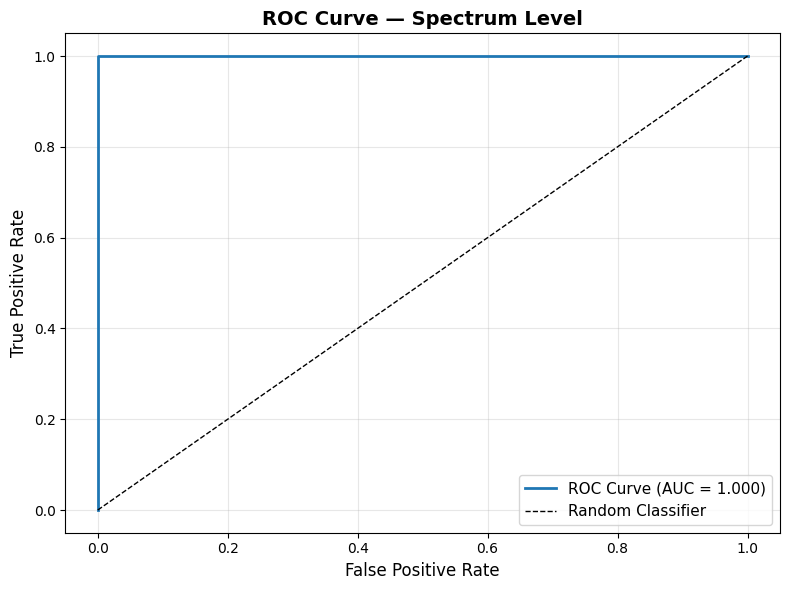


Held-out Test Set Performance (PERSON LEVEL):
 Accuracy  Balanced_Accuracy  Precision  Recall    F1  Specificity  Sensitivity   MCC  ROC_AUC
    1.000              1.000      1.000   1.000 1.000        1.000        1.000 1.000    1.000


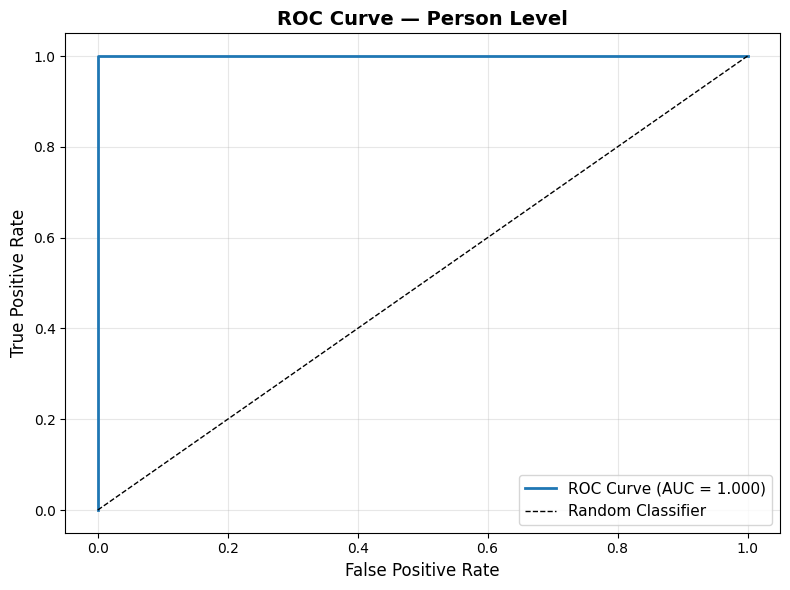


Person-level Confusion Matrix:
[[6 0]
 [0 4]]


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:29:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:29:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:29:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:29:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

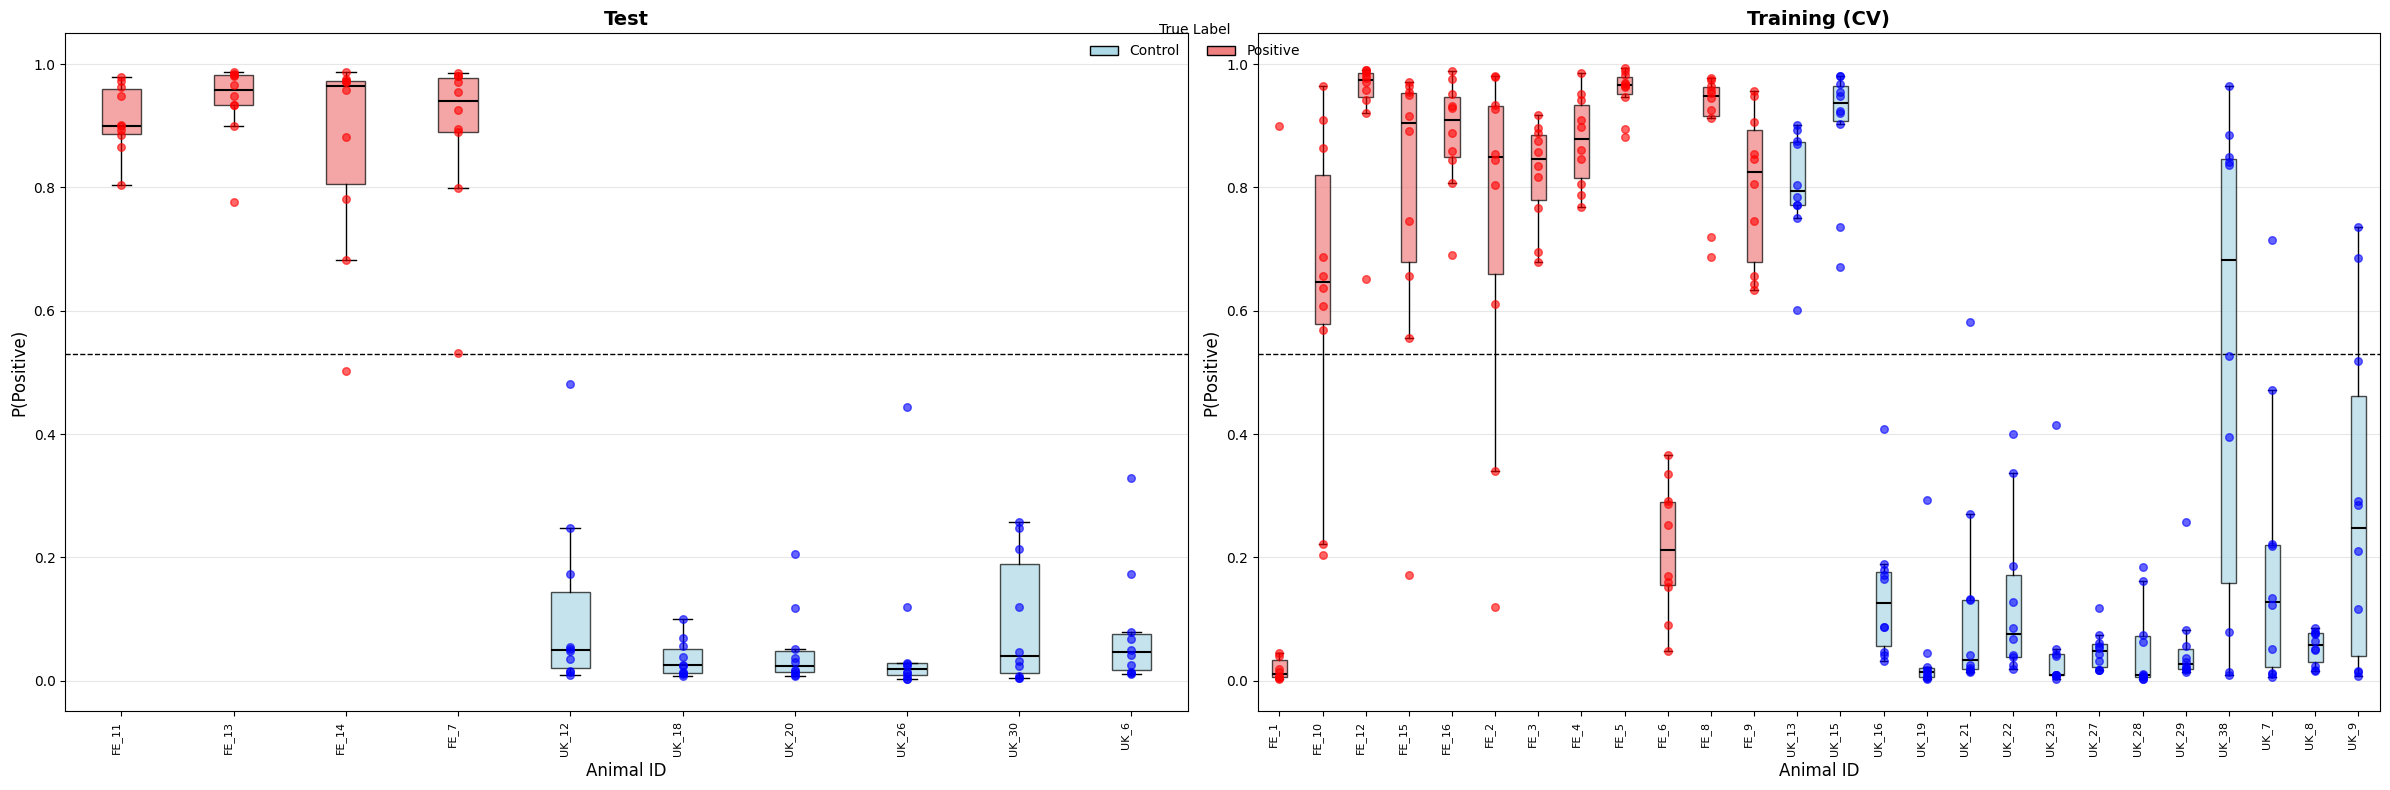

In [12]:
# ─────────────────────────────────────────
# STEP 1 — FEATURE SELECTION
# ─────────────────────────────────────────

selected_indices, ga_object = run_feature_selection(
    FEATURE_SELECTION, X_train, y_train, MODEL
)

X_train_sel = X_train[:, selected_indices]
X_test_sel  = X_test[:, selected_indices]
n_features  = X_train.shape[1]

# ─────────────────────────────────────────
# STEP 2 — VISUALIZE FEATURE SELECTION (GA only)
# ─────────────────────────────────────────

if ga_object is not None:
    best_features    = ga_object.best_chromosome
    baseline_model   = get_model(MODEL)
    ga_model_cv      = get_model(MODEL)

    # Quick CV accuracy comparison: all features vs GA selected
    def quick_cv_acc(model_name, X_data, y_data, cv=5):
        kf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_SEED)
        accs = []
        for tr, val in kf.split(X_data, y_data):
            m = get_model(model_name)
            m.fit(X_data[tr], y_data[tr])
            s = get_scores(m, X_data[val])
            accs.append(accuracy_score(y_data[val], (s >= THRESHOLD).astype(int)))
        return np.array(accs)

    baseline_scores = quick_cv_acc(MODEL, X_train, y_train)
    ga_scores       = quick_cv_acc(MODEL, X_train_sel, y_train)

    print(f"\nBaseline (all {n_features} features): "
          f"{baseline_scores.mean():.4f} ± {baseline_scores.std():.4f}")
    print(f"GA selected ({len(selected_indices)} features):  "
          f"{ga_scores.mean():.4f} ± {ga_scores.std():.4f}")

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(ga_object.best_fitness_history, label="Best Fitness", color="green")
    axes[0].plot(ga_object.avg_fitness_history,  label="Avg Fitness",  color="blue", linestyle="--")
    axes[0].set_title("GA Convergence")
    axes[0].set_xlabel("Generation")
    axes[0].set_ylabel("Fitness")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].bar(range(n_features), best_features, color="steelblue", alpha=0.7)
    axes[1].set_title("Selected Wavenumber Features")
    axes[1].set_xlabel("Wavenumber Index")
    axes[1].set_ylabel("Selected (1) / Not Selected (0)")
    axes[1].grid(True)

    labels = [f"All Features\n(n={n_features})", f"GA Selected\n(n={len(selected_indices)})"]
    means  = [baseline_scores.mean(), ga_scores.mean()]
    stds   = [baseline_scores.std(),  ga_scores.std()]
    axes[2].bar(labels, means, yerr=stds, color=["orange", "green"], alpha=0.8, capsize=8)
    axes[2].set_title("Accuracy Comparison")
    axes[2].set_ylabel("Cross-Validated Accuracy")
    axes[2].set_ylim(0, 1)
    axes[2].grid(True, axis="y")

    plt.tight_layout()
    plt.savefig("ga_feature_selection.png", dpi=150, bbox_inches="tight")
    plt.show()

# ─────────────────────────────────────────
# STEP 3 — HYPERPARAMETER TUNING
# ─────────────────────────────────────────

best_param, cv_results = tune_hyperparams(
    MODEL, X_train_sel, y_train, groups_train, cv=5
)

# ─────────────────────────────────────────
# STEP 4 — THRESHOLD OPTIMIZATION
# Uses out-of-fold predictions on training set
# ─────────────────────────────────────────

train_oof_scores = get_cv_predictions(
    MODEL, best_param, X_train_sel, y_train, groups_train, cv=5
)

thresholds = np.linspace(0, 1, 101)
best_threshold = 0.5
max_mcc = -1

for t in thresholds:
    y_pred_t = (train_oof_scores >= t).astype(int)
    cur_mcc  = matthews_corrcoef(y_train, y_pred_t)
    if cur_mcc > max_mcc:
        max_mcc        = cur_mcc
        best_threshold = t

THRESHOLD = best_threshold
print(f"\nOptimal Threshold (by MCC): {THRESHOLD:.2f}")
print(f"Best Training MCC at threshold: {max_mcc:.3f}")

train_oof_metrics = compute_metrics(y_train, train_oof_scores, threshold=THRESHOLD)
print(f"\nTraining OOF Metrics:\n{pd.DataFrame([train_oof_metrics])}")

# ─────────────────────────────────────────
# STEP 5 — FINAL MODEL: TRAIN & TEST
# Spectrum-level evaluation
# ─────────────────────────────────────────

param_name  = {"PLS": "n_components", "SVM": "C", "RF": "n_estimators", 'XGB': 'n_estimators'}[MODEL]
final_model = get_model(MODEL, **{param_name: best_param})
final_model.fit(X_train_sel, y_train)

y_test_score = get_scores(final_model, X_test_sel)
test_metrics = compute_metrics(y_test, y_test_score, threshold=THRESHOLD)

print("\nHeld-out Test Set Performance (SPECTRUM LEVEL):")
print(pd.DataFrame([test_metrics]).to_string(index=False, float_format="%.3f"))
plot_roc_curve(y_test, y_test_score, title="ROC Curve — Spectrum Level")

# ─────────────────────────────────────────
# STEP 6 — PERSON-LEVEL AGGREGATION & METRICS
# ─────────────────────────────────────────

test_df_agg = pd.DataFrame({
    "person_id": groups_test,
    "y_true":    y_test,
    "y_score":   y_test_score
})

person_df = (
    test_df_agg
    .groupby("person_id")
    .agg(y_true=("y_true", "first"), y_score=("y_score", "mean"))
    .reset_index()
)

person_metrics = compute_metrics(
    person_df["y_true"].values,
    person_df["y_score"].values,
    threshold=THRESHOLD
)

print("\nHeld-out Test Set Performance (PERSON LEVEL):")
print(pd.DataFrame([person_metrics]).to_string(index=False, float_format="%.3f"))

plot_roc_curve(
    person_df["y_true"].values,
    person_df["y_score"].values,
    title="ROC Curve — Person Level"
)

y_pred_person = (person_df["y_score"].values >= THRESHOLD).astype(int)
cm = confusion_matrix(person_df["y_true"].values, y_pred_person)
print("\nPerson-level Confusion Matrix:")
print(cm)

# ─────────────────────────────────────────
# STEP 7 — BOX PLOT (Test & Training CV)
# Per-person P(Positive) colored by true label
# ─────────────────────────────────────────

# Re-generate training OOF scores with final best_param for box plot
train_oof_scores_plot = get_cv_predictions(
    MODEL, best_param, X_train_sel, y_train, groups_train, cv=5
)

train_df = pd.DataFrame({
    "Animal_ID":  groups_train,
    "True_Label": y_train,
    "Probability": train_oof_scores_plot,
    "Dataset":    "Training"
})

test_df_plot = pd.DataFrame({
    "Animal_ID":  groups_test,
    "True_Label": y_test,
    "Probability": y_test_score,
    "Dataset":    "Test"
})

df_combined = pd.concat([train_df, test_df_plot], ignore_index=True)


def create_boxplot(ax, data, title):
    animal_ids = sorted(data["Animal_ID"].unique())
    positions  = np.arange(len(animal_ids))

    box_data_control  = []
    box_data_positive = []

    for aid in animal_ids:
        adf = data[data["Animal_ID"] == aid]
        box_data_control.append(adf[adf["True_Label"] == 0]["Probability"].values)
        box_data_positive.append(adf[adf["True_Label"] == 1]["Probability"].values)

    for i, aid in enumerate(animal_ids):
        if len(box_data_control[i]) > 0:
            ax.boxplot([box_data_control[i]], positions=[i], widths=0.35,
                       patch_artist=True,
                       boxprops=dict(facecolor="lightblue", edgecolor="black", alpha=0.7),
                       medianprops=dict(color="black", linewidth=1.5),
                       whiskerprops=dict(color="black"),
                       capprops=dict(color="black"),
                       showfliers=False)
            ax.scatter([i] * len(box_data_control[i]), box_data_control[i],
                       alpha=0.6, s=30, color="blue", zorder=3)

        if len(box_data_positive[i]) > 0:
            ax.boxplot([box_data_positive[i]], positions=[i], widths=0.35,
                       patch_artist=True,
                       boxprops=dict(facecolor="lightcoral", edgecolor="black", alpha=0.7),
                       medianprops=dict(color="black", linewidth=1.5),
                       whiskerprops=dict(color="black"),
                       capprops=dict(color="black"),
                       showfliers=False)
            ax.scatter([i] * len(box_data_positive[i]), box_data_positive[i],
                       alpha=0.6, s=30, color="red", zorder=3)

    ax.axhline(y=THRESHOLD, color="black", linestyle="--", linewidth=1)
    ax.set_xlabel("Animal ID", fontsize=12)
    ax.set_ylabel("P(Positive)", fontsize=12)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xticks(positions)
    ax.set_xticklabels(animal_ids, rotation=90, ha="right", fontsize=8)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(axis="y", alpha=0.3)


fig, axes = plt.subplots(1, 2, figsize=(24, 8))

create_boxplot(axes[0], df_combined[df_combined["Dataset"] == "Test"],      "Test")
create_boxplot(axes[1], df_combined[df_combined["Dataset"] == "Training"],  "Training (CV)")

legend_elements = [
    Patch(facecolor="lightblue",  edgecolor="black", label="Control"),
    Patch(facecolor="lightcoral", edgecolor="black", label="Positive"),
]
fig.legend(legend_elements, ["Control", "Positive"],
           loc="upper center", ncol=2, frameon=False,
           title="True Label", bbox_to_anchor=(0.5, 0.98), fontsize=10)

plt.tight_layout()
plt.subplots_adjust()
plt.show()